## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')



In [3]:
# ── Load Dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv(r"D:\Downloads\bda_dataset_2.csv")
df.columns = df.columns.str.strip()
df.rename(columns={
    'Fast Delivery Agent Reviews.Rating': 'delivery_rating',
    'Fast Delivery Agent Reviews.Delivery Time (min)': 'delivery_time_min',
    'platform (groups)': 'platform_group'
}, inplace=True)

# Clean nulls for key columns
df_clean = df.dropna(subset=['customer_rating', 'sentiment', 'region', 'product_category'])
df_clean = df_clean.copy()
df_clean['customer_rating'] = df_clean['customer_rating'].astype(float)
df_clean['response_time_hours'] = pd.to_numeric(df_clean['response_time_hours'], errors='coerce')

print(f"Dataset Shape: {df.shape}")
print(f"Clean Dataset Shape: {df_clean.shape}")
print(f"\nColumns:\n{df.dtypes}")
print(f"\nFirst 5 rows:\n{df.head()}")

Dataset Shape: (1048575, 14)
Clean Dataset Shape: (1048575, 14)

Columns:
customer_id               int64
region                   object
product_category         object
purchase_channel         object
platform                 object
customer_rating           int64
review_text              object
sentiment                object
response_time_hours       int64
issue_resolved           object
complaint_registered     object
delivery_rating         float64
delivery_time_min       float64
platform_group           object
dtype: object

First 5 rows:
   customer_id region product_category purchase_channel platform  \
0          513   east           travel           online  jiomart   
1          513   east           travel           online  jiomart   
2          513   east           travel           online  jiomart   
3          513   east           travel           online  jiomart   
4          513   east           travel           online  jiomart   

   customer_rating                      

## EDA

In [5]:
print("=" * 60)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 60)

print(f"\nCustomer Rating Distribution:\n{df_clean['customer_rating'].value_counts().sort_index()}")
print(f"\nSentiment Distribution:\n{df_clean['sentiment'].value_counts()}")
print(f"\nRegion Distribution:\n{df_clean['region'].value_counts()}")
print(f"\nProduct Category Distribution:\n{df_clean['product_category'].value_counts()}")
print(f"\nTop 10 Platforms:\n{df_clean['platform_group'].value_counts().head(10)}")
print(f"\nPurchase Channel:\n{df_clean['purchase_channel'].value_counts()}")
print(f"\nDescriptive Stats:\n{df_clean[['customer_rating','response_time_hours']].describe()}")

EXPLORATORY DATA ANALYSIS

Customer Rating Distribution:
customer_rating
1.0    184567
2.0    228715
3.0    200006
4.0    230784
5.0    204503
Name: count, dtype: int64

Sentiment Distribution:
sentiment
positive    435287
negative    413282
neutral     200006
Name: count, dtype: int64

Region Distribution:
region
south      220953
east       214293
central    211220
west       209379
north      192730
Name: count, dtype: int64

Product Category Distribution:
product_category
groceries         128623
home & kitchen    126268
fashion           123432
travel            121799
books             118186
sports            113838
beauty            113781
automobile        102414
electronics       100234
Name: count, dtype: int64

Top 10 Platforms:
platform_group
jiomart             353466
swiggy instamart    351936
zepto               338448
bigbasket              293
nykaa                  292
reliance digital       292
lenskart               289
flipkart               286
paytm mall        

## Visual Analytics Dashboard

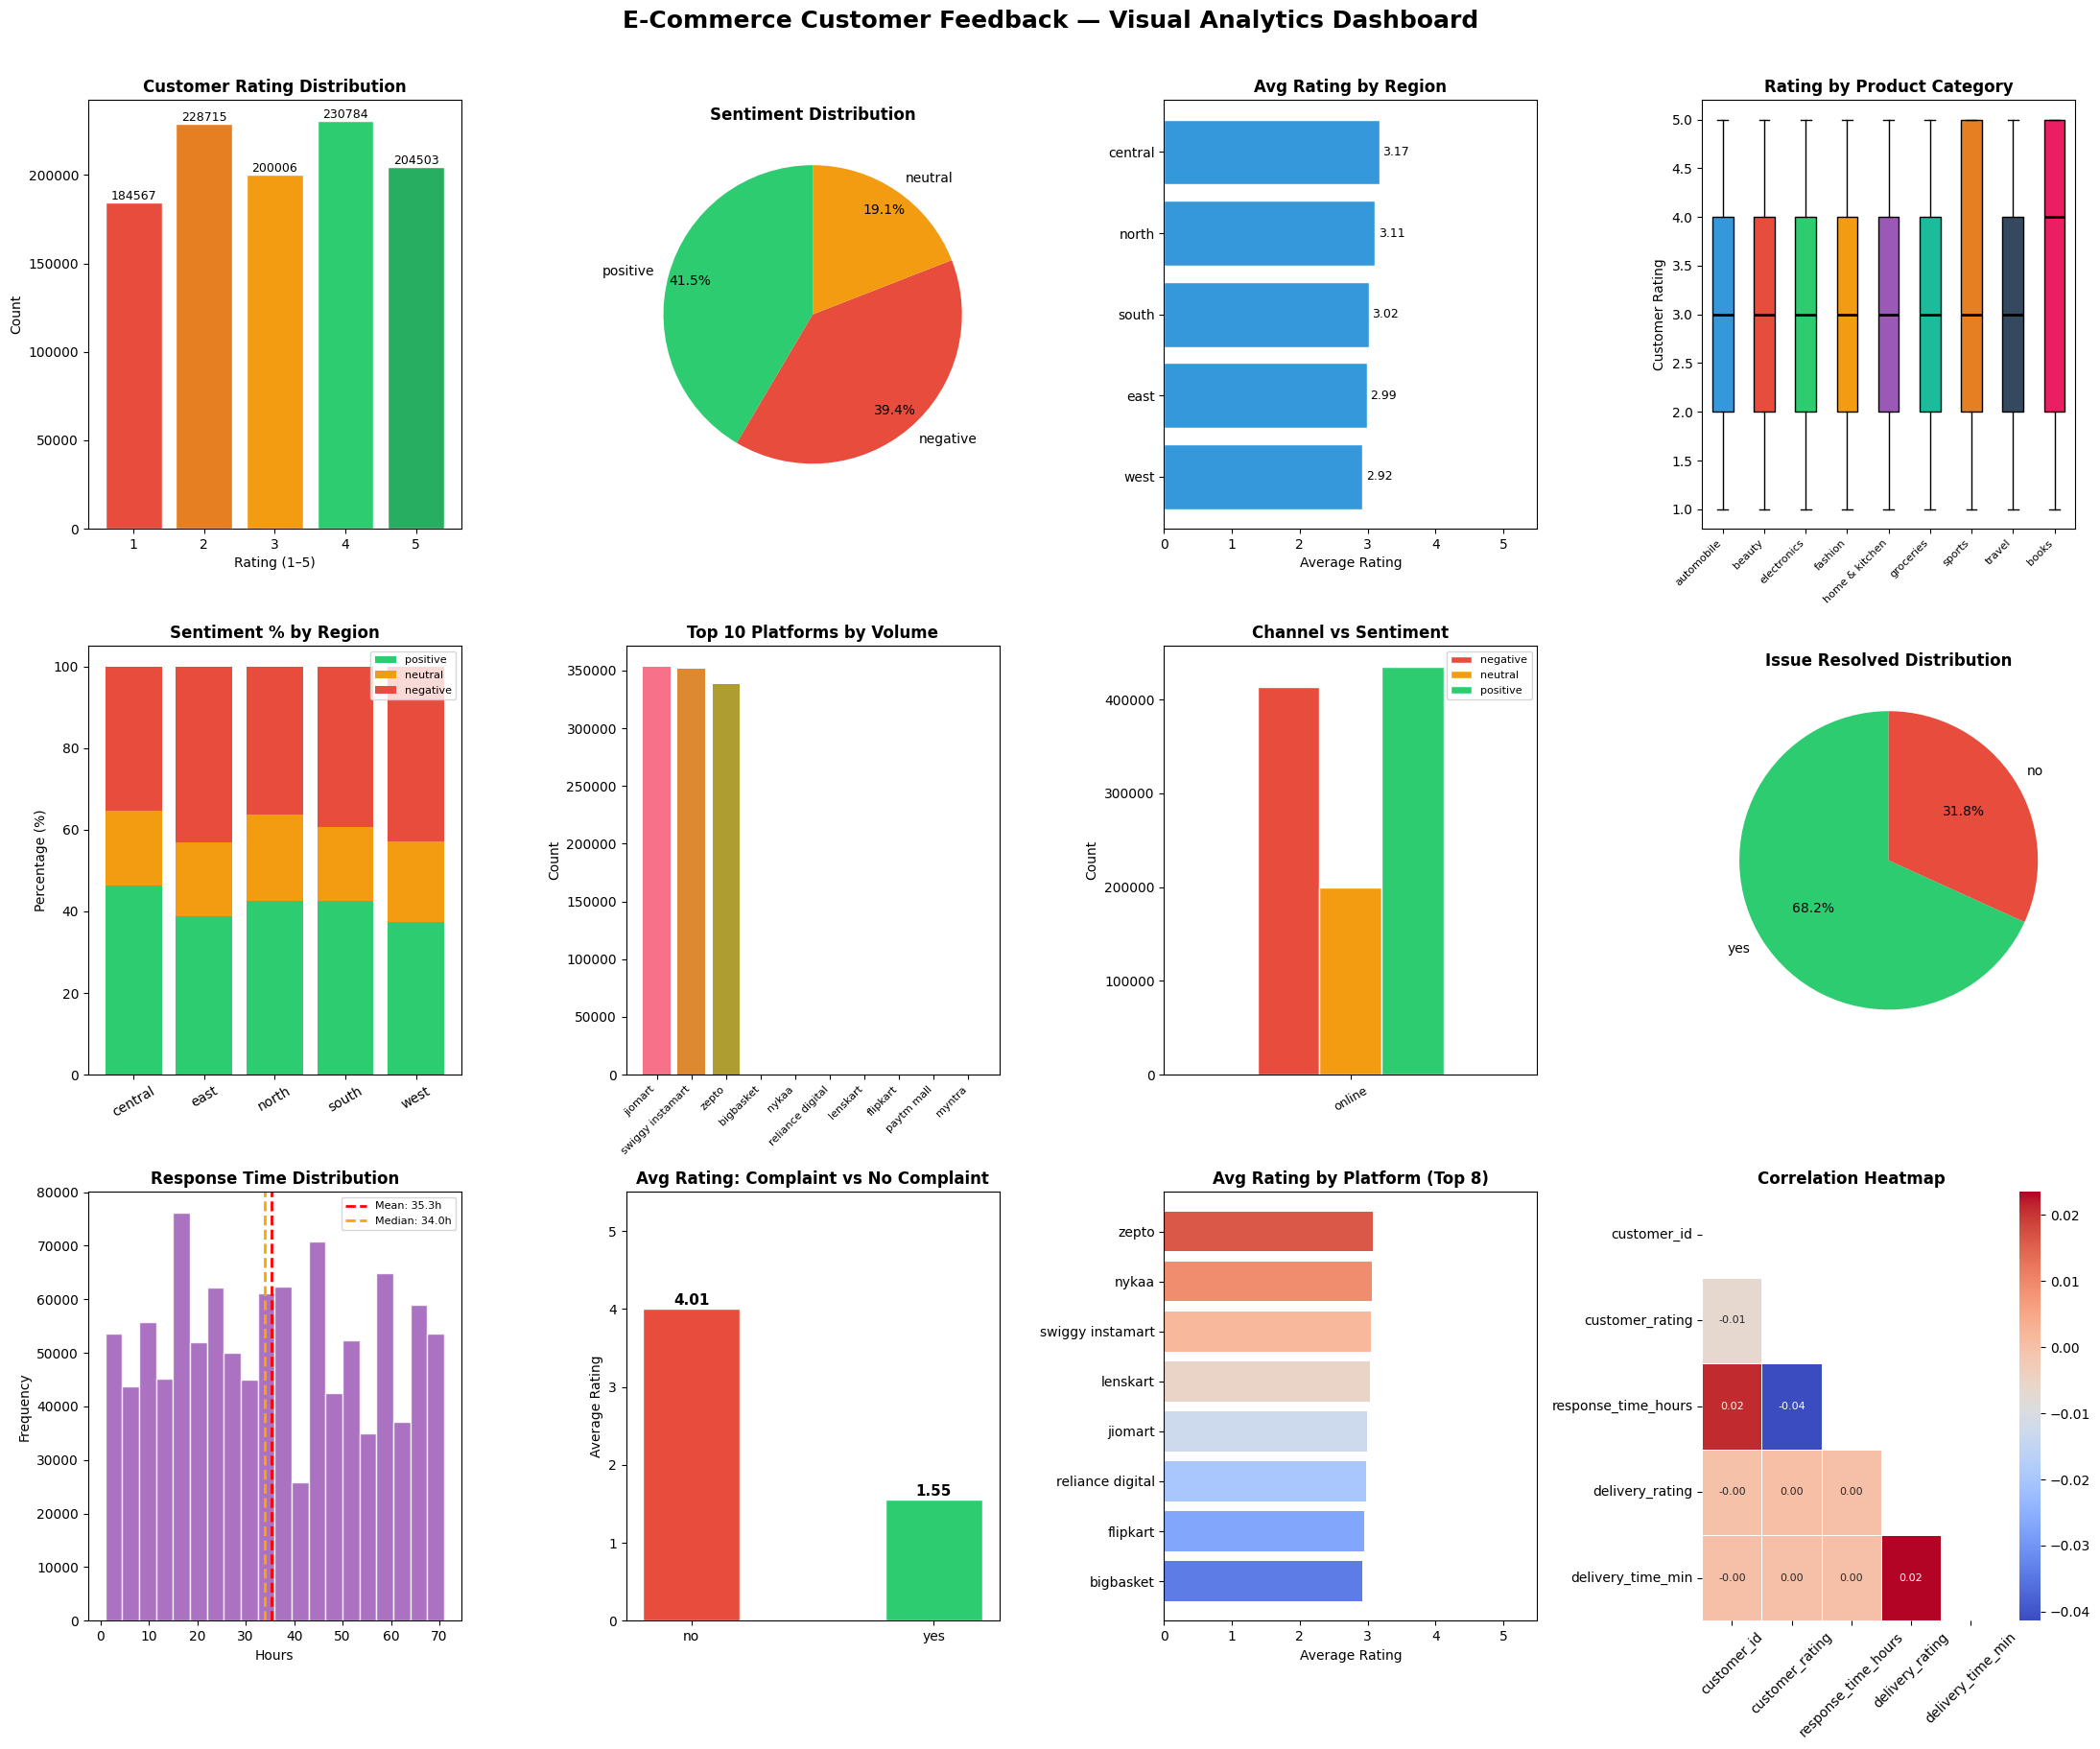

Dashboard saved as dashboard_visual_analytics.png


In [4]:
fig = plt.figure(figsize=(22, 18))
fig.suptitle("E-Commerce Customer Feedback — Visual Analytics Dashboard",
             fontsize=18, fontweight='bold', y=1.01)

colors_sentiment = {'positive': '#2ecc71', 'neutral': '#f39c12', 'negative': '#e74c3c'}
palette = ['#3498db','#e74c3c','#2ecc71','#f39c12','#9b59b6','#1abc9c','#e67e22','#34495e','#e91e63']

# ── 1. Customer Rating Distribution (Bar) ────────────────────────────────────
ax1 = fig.add_subplot(3, 4, 1)
rating_counts = df_clean['customer_rating'].value_counts().sort_index()
bars = ax1.bar(rating_counts.index, rating_counts.values,
               color=['#e74c3c','#e67e22','#f39c12','#2ecc71','#27ae60'], edgecolor='white')
ax1.set_title("Customer Rating Distribution", fontweight='bold')
ax1.set_xlabel("Rating (1–5)")
ax1.set_ylabel("Count")
for bar, val in zip(bars, rating_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', va='bottom', fontsize=9)

# ── 2. Sentiment Pie Chart ────────────────────────────────────────────────────
ax2 = fig.add_subplot(3, 4, 2)
sent_counts = df_clean['sentiment'].value_counts()
colors_pie = [colors_sentiment.get(s, '#95a5a6') for s in sent_counts.index]
wedges, texts, autotexts = ax2.pie(sent_counts.values, labels=sent_counts.index,
                                    autopct='%1.1f%%', colors=colors_pie,
                                    startangle=90, pctdistance=0.85)
ax2.set_title("Sentiment Distribution", fontweight='bold')

# ── 3. Region-wise Avg Rating (Horizontal Bar) ───────────────────────────────
ax3 = fig.add_subplot(3, 4, 3)
region_rating = df_clean.groupby('region')['customer_rating'].mean().sort_values()
bars3 = ax3.barh(region_rating.index, region_rating.values, color='#3498db', edgecolor='white')
ax3.set_title("Avg Rating by Region", fontweight='bold')
ax3.set_xlabel("Average Rating")
ax3.set_xlim(0, 5.5)
for bar, val in zip(bars3, region_rating.values):
    ax3.text(val + 0.05, bar.get_y() + bar.get_height()/2,
             f"{val:.2f}", va='center', fontsize=9)

# ── 4. Product Category vs Rating (Box Plot) ─────────────────────────────────
ax4 = fig.add_subplot(3, 4, 4)
cat_order = df_clean.groupby('product_category')['customer_rating'].median().sort_values().index
data_by_cat = [df_clean[df_clean['product_category'] == c]['customer_rating'].dropna().values
               for c in cat_order]
bp = ax4.boxplot(data_by_cat, labels=cat_order, patch_artist=True,
                 medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], palette):
    patch.set_facecolor(color)
ax4.set_title("Rating by Product Category", fontweight='bold')
ax4.set_xticklabels(cat_order, rotation=45, ha='right', fontsize=8)
ax4.set_ylabel("Customer Rating")

# ── 5. Sentiment by Region (Stacked Bar) ─────────────────────────────────────
ax5 = fig.add_subplot(3, 4, 5)
region_sent = df_clean.groupby(['region', 'sentiment']).size().unstack(fill_value=0)
region_sent_pct = region_sent.div(region_sent.sum(axis=1), axis=0) * 100
bottom = np.zeros(len(region_sent_pct))
for sentiment, color in colors_sentiment.items():
    if sentiment in region_sent_pct.columns:
        ax5.bar(region_sent_pct.index, region_sent_pct[sentiment],
                bottom=bottom, label=sentiment, color=color)
        bottom += region_sent_pct[sentiment].values
ax5.set_title("Sentiment % by Region", fontweight='bold')
ax5.set_ylabel("Percentage (%)")
ax5.legend(loc='upper right', fontsize=8)
ax5.set_xticklabels(region_sent_pct.index, rotation=30)

# ── 6. Top 10 Platforms by Count (Bar) ───────────────────────────────────────
ax6 = fig.add_subplot(3, 4, 6)
top_platforms = df_clean['platform_group'].value_counts().head(10)
ax6.bar(top_platforms.index, top_platforms.values,
        color=sns.color_palette("husl", 10))
ax6.set_title("Top 10 Platforms by Volume", fontweight='bold')
ax6.set_ylabel("Count")
ax6.set_xticklabels(top_platforms.index, rotation=45, ha='right', fontsize=8)

# ── 7. Purchase Channel vs Sentiment (Grouped Bar) ───────────────────────────
ax7 = fig.add_subplot(3, 4, 7)
ch_sent = df_clean.groupby(['purchase_channel', 'sentiment']).size().unstack(fill_value=0)
ch_sent.plot(kind='bar', ax=ax7,
             color=[colors_sentiment.get(c, '#95a5a6') for c in ch_sent.columns],
             edgecolor='white')
ax7.set_title("Channel vs Sentiment", fontweight='bold')
ax7.set_xlabel("")
ax7.set_ylabel("Count")
ax7.set_xticklabels(ch_sent.index, rotation=30, fontsize=9)
ax7.legend(fontsize=8)

# ── 8. Issue Resolved Distribution ───────────────────────────────────────────
ax8 = fig.add_subplot(3, 4, 8)
issue_counts = df_clean['issue_resolved'].value_counts()
ax8.pie(issue_counts.values, labels=issue_counts.index,
        autopct='%1.1f%%', colors=['#2ecc71','#e74c3c','#f39c12'],
        startangle=90)
ax8.set_title("Issue Resolved Distribution", fontweight='bold')

# ── 9. Response Time Histogram ────────────────────────────────────────────────
ax9 = fig.add_subplot(3, 4, 9)
rt = df_clean['response_time_hours'].dropna()
ax9.hist(rt, bins=20, color='#9b59b6', edgecolor='white', alpha=0.85)
ax9.axvline(rt.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {rt.mean():.1f}h')
ax9.axvline(rt.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {rt.median():.1f}h')
ax9.set_title("Response Time Distribution", fontweight='bold')
ax9.set_xlabel("Hours")
ax9.set_ylabel("Frequency")
ax9.legend(fontsize=8)

# ── 10. Complaint Registered vs Rating ───────────────────────────────────────
ax10 = fig.add_subplot(3, 4, 10)
comp_rating = df_clean.groupby('complaint_registered')['customer_rating'].mean()
ax10.bar(comp_rating.index, comp_rating.values,
         color=['#e74c3c', '#2ecc71'], edgecolor='white', width=0.4)
ax10.set_title("Avg Rating: Complaint vs No Complaint", fontweight='bold')
ax10.set_ylabel("Average Rating")
ax10.set_ylim(0, 5.5)
for i, (label, val) in enumerate(comp_rating.items()):
    ax10.text(i, val + 0.05, f"{val:.2f}", ha='center', fontsize=11, fontweight='bold')

# ── 11. Rating by Platform (Top 8) ───────────────────────────────────────────
ax11 = fig.add_subplot(3, 4, 11)
top8_plat = df_clean['platform_group'].value_counts().head(8).index
df_top8 = df_clean[df_clean['platform_group'].isin(top8_plat)]
plat_rating = df_top8.groupby('platform_group')['customer_rating'].mean().sort_values()
ax11.barh(plat_rating.index, plat_rating.values,
          color=sns.color_palette("coolwarm", len(plat_rating)))
ax11.set_title("Avg Rating by Platform (Top 8)", fontweight='bold')
ax11.set_xlabel("Average Rating")
ax11.set_xlim(0, 5.5)

# ── 12. Correlation Heatmap ───────────────────────────────────────────────────
ax12 = fig.add_subplot(3, 4, 12)
numeric_cols = df_clean.select_dtypes(include=[np.number]).dropna(axis=1, how='all')
corr = numeric_cols.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax12, annot=True, fmt=".2f", cmap='coolwarm',
            mask=mask, linewidths=0.5, annot_kws={"size": 8})
ax12.set_title("Correlation Heatmap", fontweight='bold')
ax12.tick_params(axis='x', rotation=45)
ax12.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig("dashboard_visual_analytics.png", dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved as dashboard_visual_analytics.png")

## Time Series Forecasting 

PART B — TIME SERIES FORECASTING
Time Series Periods: 10485
Avg Rating Series:
count    10485.000000
mean         3.040144
std          1.364631
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: avg_rating, dtype: float64

Avg Response Time Series:
count    10485.000000
mean        35.266274
std         19.917167
min          1.000000
25%         18.000000
50%         35.000000
75%         52.000000
max         71.000000
Name: avg_response_time, dtype: float64


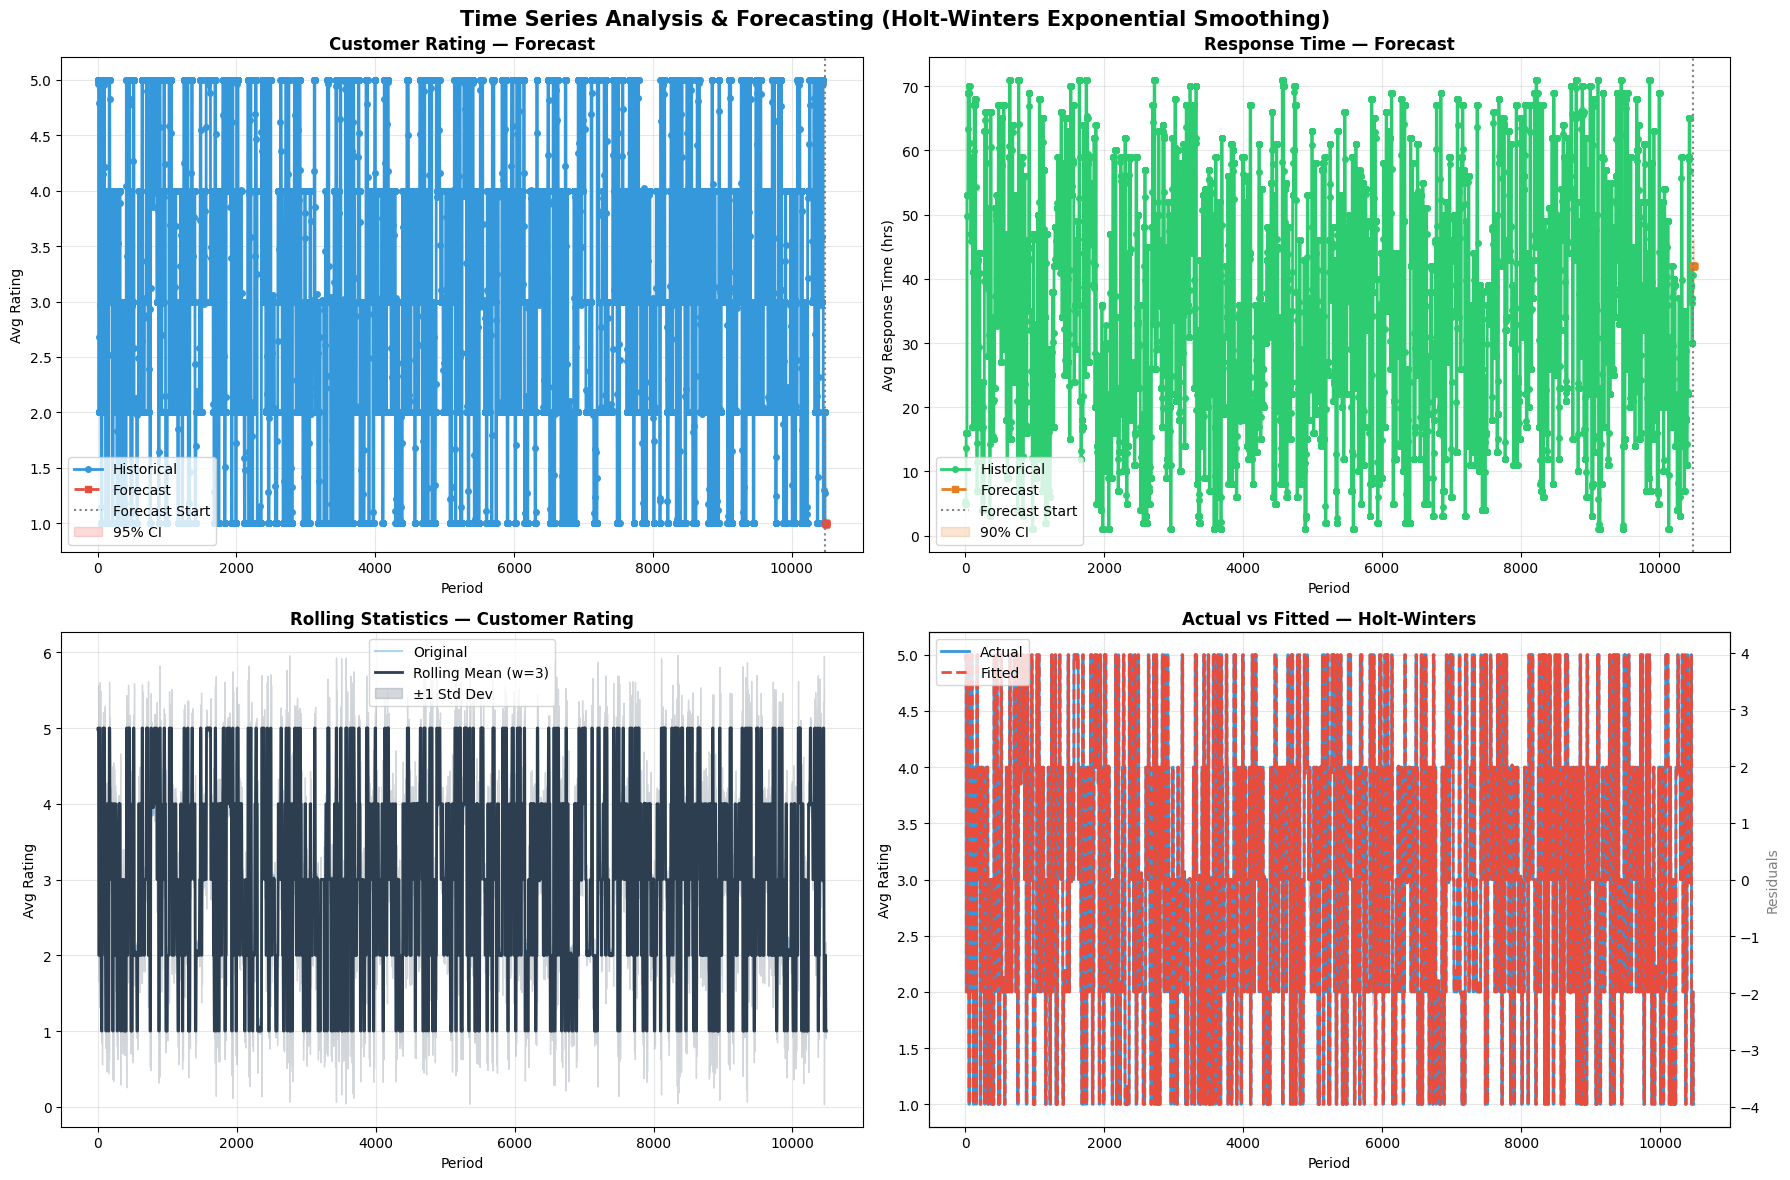


Forecast Summary (Next 10 periods):
  Customer Rating  → 0.998 (avg forecasted)
  Response Time    → 42.02 hrs (avg forecasted)


In [6]:
# ── Build synthetic time series from customer_id order (proxy for time) ──────
print("=" * 60)
print("PART B — TIME SERIES FORECASTING")
print("=" * 60)

df_ts = df_clean[['customer_id','customer_rating','response_time_hours']].dropna().copy()
df_ts = df_ts.sort_values('customer_id').reset_index(drop=True)

# Create rolling weekly average (every 100 customers as a "period")
period_size = 100
n_periods = len(df_ts) // period_size
ts_rating = []
ts_response = []

for i in range(n_periods):
    chunk = df_ts.iloc[i*period_size:(i+1)*period_size]
    ts_rating.append(chunk['customer_rating'].mean())
    ts_response.append(chunk['response_time_hours'].mean())

ts_rating = pd.Series(ts_rating, name='avg_rating')
ts_response = pd.Series(ts_response, name='avg_response_time')
x_axis = np.arange(1, n_periods + 1)

print(f"Time Series Periods: {n_periods}")
print(f"Avg Rating Series:\n{ts_rating.describe()}")
print(f"\nAvg Response Time Series:\n{ts_response.describe()}")

# ── Holt-Winters Exponential Smoothing Forecast ───────────────────────────────
forecast_periods = 10

# Rating forecast
model_rating = ExponentialSmoothing(ts_rating, trend='add', seasonal=None,
                                     initialization_method='estimated').fit(optimized=True)
forecast_rating = model_rating.forecast(forecast_periods)

# Response time forecast
model_response = ExponentialSmoothing(ts_response, trend='add', seasonal=None,
                                       initialization_method='estimated').fit(optimized=True)
forecast_response = model_response.forecast(forecast_periods)

# ── Plot Forecasts ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Time Series Analysis & Forecasting (Holt-Winters Exponential Smoothing)",
             fontsize=15, fontweight='bold')

# Plot 1: Rating Historical + Forecast
ax = axes[0, 0]
ax.plot(x_axis, ts_rating, color='#3498db', linewidth=2, marker='o', markersize=4, label='Historical')
ax.plot(np.arange(n_periods+1, n_periods+forecast_periods+1), forecast_rating,
        color='#e74c3c', linewidth=2, marker='s', markersize=4, linestyle='--', label='Forecast')
ax.axvline(n_periods, color='gray', linestyle=':', linewidth=1.5, label='Forecast Start')
ax.fill_between(np.arange(n_periods+1, n_periods+forecast_periods+1),
                forecast_rating * 0.95, forecast_rating * 1.05, alpha=0.2, color='#e74c3c', label='95% CI')
ax.set_title("Customer Rating — Forecast", fontweight='bold')
ax.set_xlabel("Period")
ax.set_ylabel("Avg Rating")
ax.legend()
ax.grid(alpha=0.3)

# Plot 2: Response Time Historical + Forecast
ax = axes[0, 1]
ax.plot(x_axis, ts_response, color='#2ecc71', linewidth=2, marker='o', markersize=4, label='Historical')
ax.plot(np.arange(n_periods+1, n_periods+forecast_periods+1), forecast_response,
        color='#e67e22', linewidth=2, marker='s', markersize=4, linestyle='--', label='Forecast')
ax.axvline(n_periods, color='gray', linestyle=':', linewidth=1.5, label='Forecast Start')
ax.fill_between(np.arange(n_periods+1, n_periods+forecast_periods+1),
                forecast_response * 0.9, forecast_response * 1.1, alpha=0.2, color='#e67e22', label='90% CI')
ax.set_title("Response Time — Forecast", fontweight='bold')
ax.set_xlabel("Period")
ax.set_ylabel("Avg Response Time (hrs)")
ax.legend()
ax.grid(alpha=0.3)

# Plot 3: Rolling Mean & Std (Rating)
ax = axes[1, 0]
rolling_mean = ts_rating.rolling(window=3).mean()
rolling_std = ts_rating.rolling(window=3).std()
ax.plot(x_axis, ts_rating, color='#3498db', alpha=0.4, label='Original')
ax.plot(x_axis, rolling_mean, color='#2c3e50', linewidth=2, label='Rolling Mean (w=3)')
ax.fill_between(x_axis,
                rolling_mean - rolling_std, rolling_mean + rolling_std,
                alpha=0.2, color='#2c3e50', label='±1 Std Dev')
ax.set_title("Rolling Statistics — Customer Rating", fontweight='bold')
ax.set_xlabel("Period")
ax.set_ylabel("Avg Rating")
ax.legend()
ax.grid(alpha=0.3)

# Plot 4: Fitted vs Actual
ax = axes[1, 1]
fitted_rating = model_rating.fittedvalues
ax.plot(x_axis, ts_rating, color='#3498db', linewidth=2, label='Actual')
ax.plot(x_axis, fitted_rating, color='#e74c3c', linewidth=2, linestyle='--', label='Fitted')
residuals = ts_rating - fitted_rating
ax2_twin = ax.twinx()
ax2_twin.bar(x_axis, residuals, alpha=0.3, color='gray', label='Residuals')
ax2_twin.set_ylabel("Residuals", color='gray')
ax.set_title("Actual vs Fitted — Holt-Winters", fontweight='bold')
ax.set_xlabel("Period")
ax.set_ylabel("Avg Rating")
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("time_series_forecast.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\nForecast Summary (Next {forecast_periods} periods):")
print(f"  Customer Rating  → {forecast_rating.mean():.3f} (avg forecasted)")
print(f"  Response Time    → {forecast_response.mean():.2f} hrs (avg forecasted)")

## Trend Analysis & Curve Fitting 


PART C — TREND ANALYSIS & PATTERN FITTING


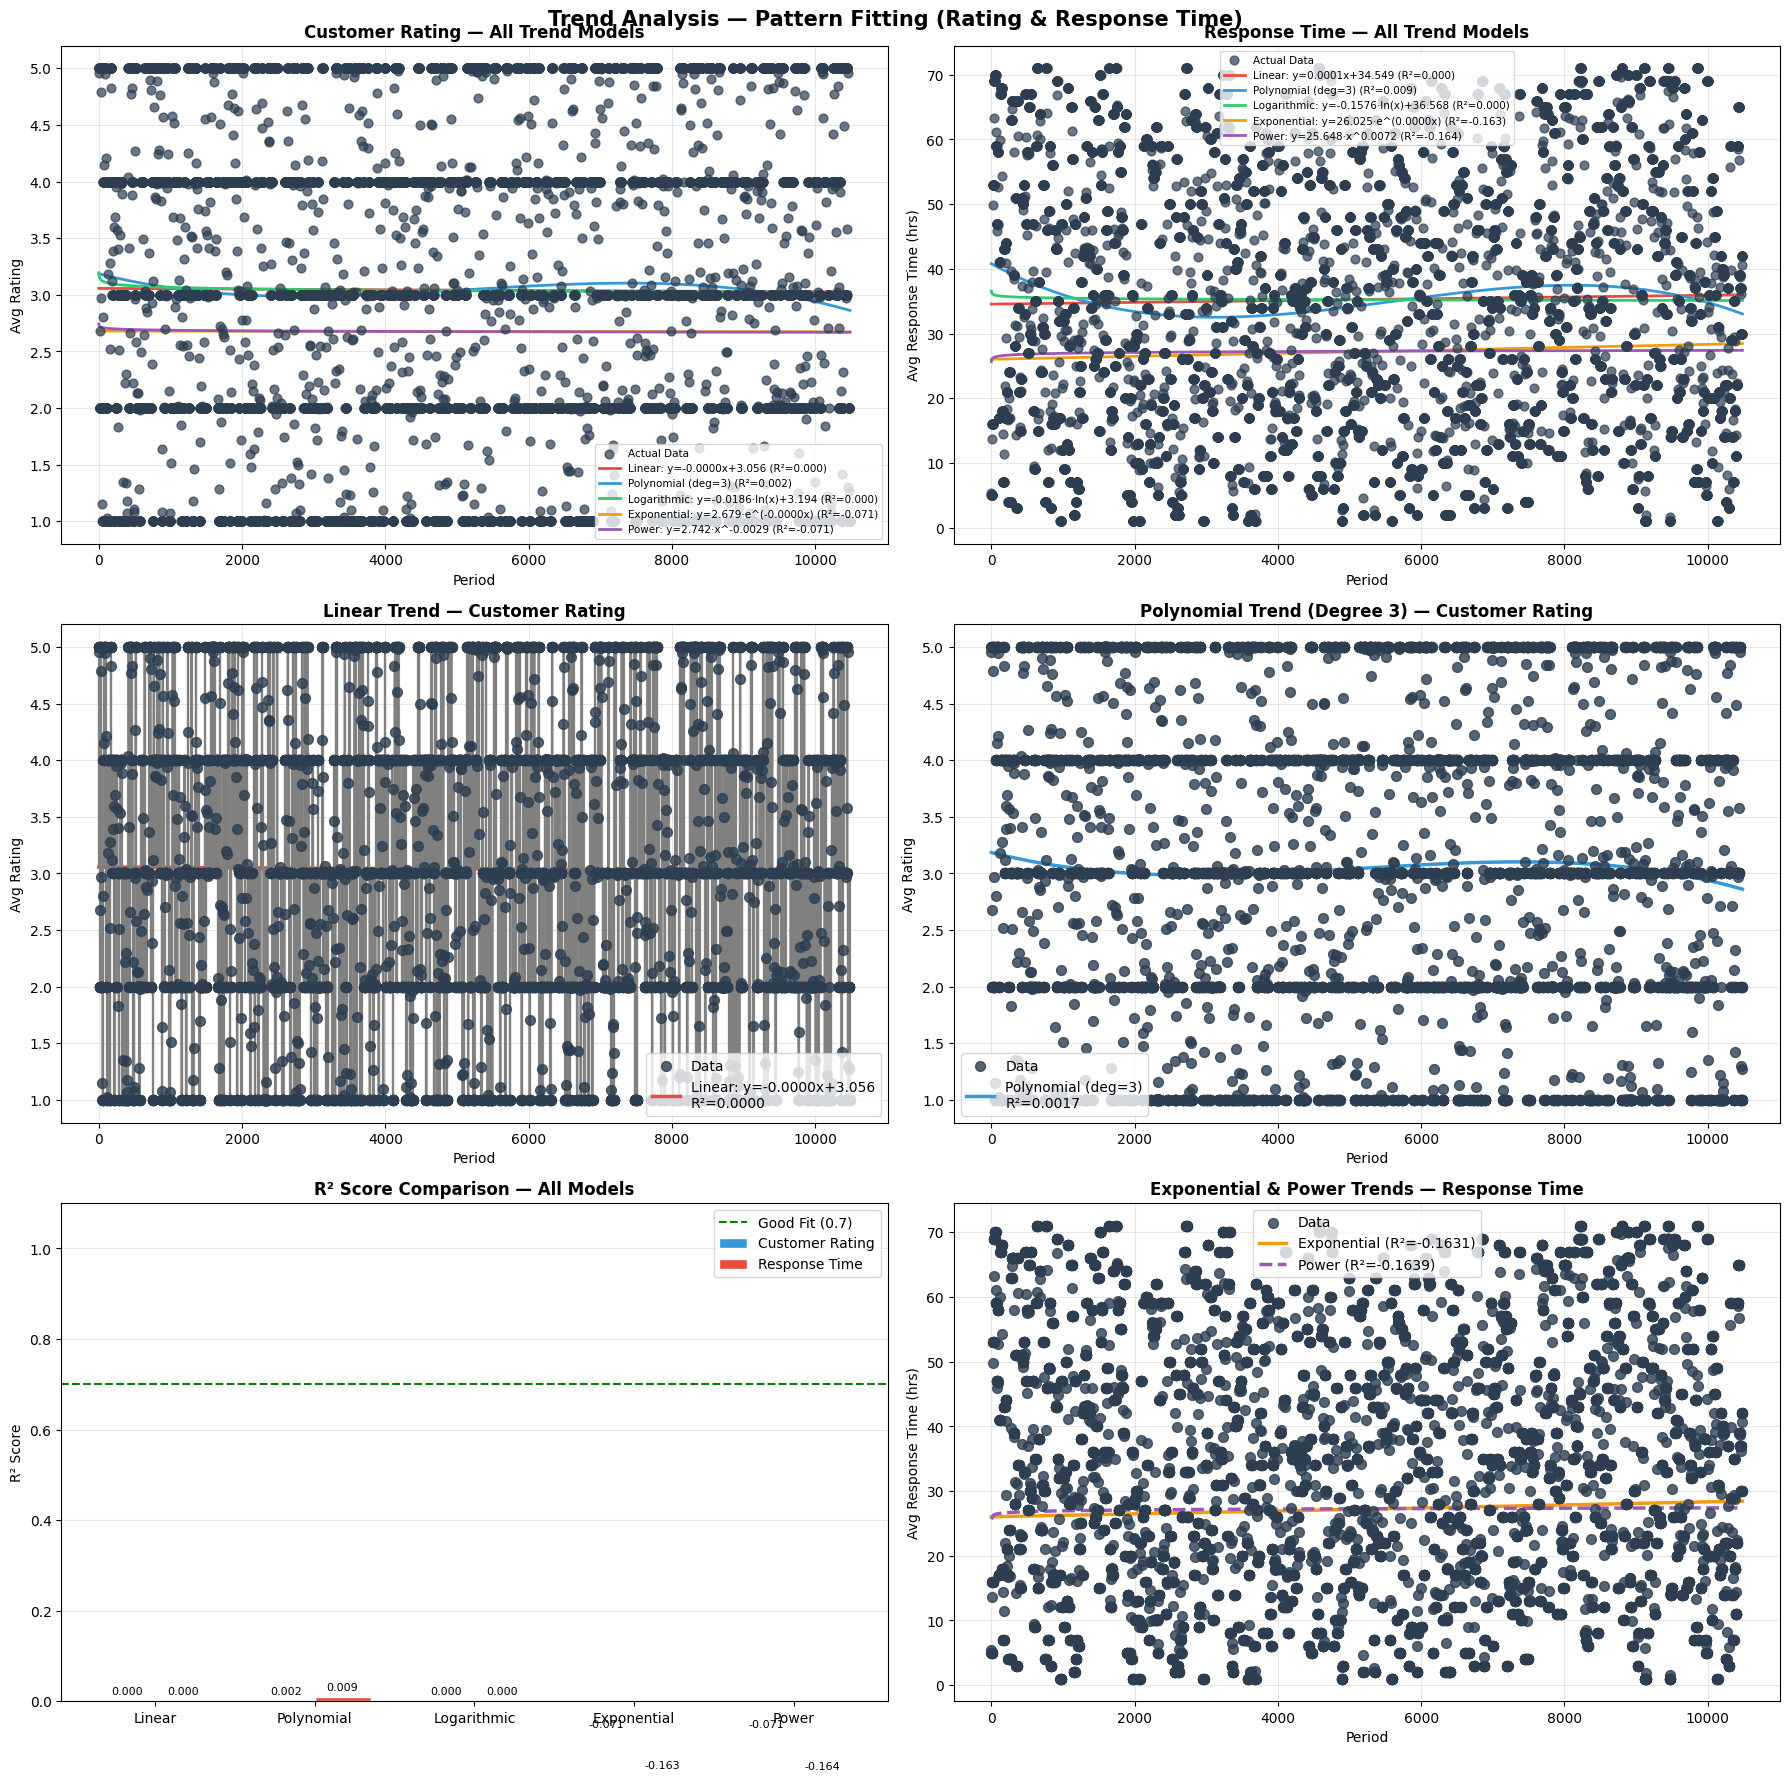


📊 R² Score Summary:
Model              Rating R²   Response R²
------------------------------------------
Linear                0.0000        0.0004
Polynomial            0.0017        0.0094
Logarithmic           0.0002        0.0001
Exponential          -0.0712       -0.1631
Power                -0.0711       -0.1639

✅ Best fit for Rating     → Polynomial (R²=0.0017)
✅ Best fit for Response   → Polynomial (R²=0.0094)


In [7]:
print("=" * 60)
print("PART C — TREND ANALYSIS & PATTERN FITTING")
print("=" * 60)

x = np.arange(1, n_periods + 1, dtype=float)
y_rating = ts_rating.values
y_response = ts_response.values

# ── Fit all 5 models to Rating vs Period ─────────────────────────────────────
def fit_and_score(x, y, model_type):
    if model_type == 'linear':
        coeffs = np.polyfit(x, y, 1)
        y_pred = np.polyval(coeffs, x)
        label = f"Linear: y={coeffs[0]:.4f}x+{coeffs[1]:.3f}"
    elif model_type == 'polynomial':
        coeffs = np.polyfit(x, y, 3)
        y_pred = np.polyval(coeffs, x)
        label = f"Polynomial (deg=3)"
    elif model_type == 'logarithmic':
        x_log = np.where(x > 0, x, 1e-6)
        coeffs = np.polyfit(np.log(x_log), y, 1)
        y_pred = coeffs[0] * np.log(x_log) + coeffs[1]
        label = f"Logarithmic: y={coeffs[0]:.4f}·ln(x)+{coeffs[1]:.3f}"
    elif model_type == 'exponential':
        y_pos = np.where(y > 0, y, 1e-6)
        coeffs = np.polyfit(x, np.log(y_pos), 1)
        y_pred = np.exp(coeffs[1]) * np.exp(coeffs[0] * x)
        label = f"Exponential: y={np.exp(coeffs[1]):.3f}·e^({coeffs[0]:.4f}x)"
    elif model_type == 'power':
        x_pos = np.where(x > 0, x, 1e-6)
        y_pos = np.where(y > 0, y, 1e-6)
        coeffs = np.polyfit(np.log(x_pos), np.log(y_pos), 1)
        y_pred = np.exp(coeffs[1]) * x_pos**coeffs[0]
        label = f"Power: y={np.exp(coeffs[1]):.3f}·x^{coeffs[0]:.4f}"
    r2 = r2_score(y, y_pred)
    return y_pred, label, r2

models = ['linear', 'polynomial', 'logarithmic', 'exponential', 'power']
model_colors = {
    'linear': '#e74c3c',
    'polynomial': '#3498db',
    'logarithmic': '#2ecc71',
    'exponential': '#f39c12',
    'power': '#9b59b6'
}

fig, axes = plt.subplots(3, 2, figsize=(18, 18))
fig.suptitle("Trend Analysis — Pattern Fitting (Rating & Response Time)",
             fontsize=15, fontweight='bold')

# ── Plot 1: All 5 models on Rating ───────────────────────────────────────────
ax = axes[0, 0]
ax.scatter(x, y_rating, color='#2c3e50', s=40, zorder=5, label='Actual Data', alpha=0.7)
for m in models:
    y_pred, label, r2 = fit_and_score(x, y_rating, m)
    ax.plot(x, y_pred, color=model_colors[m], linewidth=2, label=f"{label} (R²={r2:.3f})")
ax.set_title("Customer Rating — All Trend Models", fontweight='bold')
ax.set_xlabel("Period")
ax.set_ylabel("Avg Rating")
ax.legend(fontsize=7.5)
ax.grid(alpha=0.3)

# ── Plot 2: All 5 models on Response Time ────────────────────────────────────
ax = axes[0, 1]
ax.scatter(x, y_response, color='#2c3e50', s=40, zorder=5, label='Actual Data', alpha=0.7)
for m in models:
    y_pred, label, r2 = fit_and_score(x, y_response, m)
    ax.plot(x, y_pred, color=model_colors[m], linewidth=2, label=f"{label} (R²={r2:.3f})")
ax.set_title("Response Time — All Trend Models", fontweight='bold')
ax.set_xlabel("Period")
ax.set_ylabel("Avg Response Time (hrs)")
ax.legend(fontsize=7.5)
ax.grid(alpha=0.3)

# ── Plot 3: Best Individual Fit — Linear ─────────────────────────────────────
ax = axes[1, 0]
y_pred_lin, label_lin, r2_lin = fit_and_score(x, y_rating, 'linear')
ax.scatter(x, y_rating, color='#2c3e50', s=50, zorder=5, alpha=0.8, label='Data')
ax.plot(x, y_pred_lin, color='#e74c3c', linewidth=2.5, label=f"{label_lin}\nR²={r2_lin:.4f}")
residuals_lin = y_rating - y_pred_lin
for i in range(len(x)):
    ax.vlines(x[i], min(y_rating[i], y_pred_lin[i]),
              max(y_rating[i], y_pred_lin[i]), colors='gray', alpha=0.4)
ax.set_title("Linear Trend — Customer Rating", fontweight='bold')
ax.set_xlabel("Period"); ax.set_ylabel("Avg Rating")
ax.legend(); ax.grid(alpha=0.3)

# ── Plot 4: Polynomial Trend ──────────────────────────────────────────────────
ax = axes[1, 1]
x_smooth = np.linspace(x.min(), x.max(), 300)
y_pred_poly, label_poly, r2_poly = fit_and_score(x, y_rating, 'polynomial')
coeffs3 = np.polyfit(x, y_rating, 3)
y_smooth_poly = np.polyval(coeffs3, x_smooth)
ax.scatter(x, y_rating, color='#2c3e50', s=50, zorder=5, alpha=0.8, label='Data')
ax.plot(x_smooth, y_smooth_poly, color='#3498db', linewidth=2.5,
        label=f"Polynomial (deg=3)\nR²={r2_poly:.4f}")
ax.set_title("Polynomial Trend (Degree 3) — Customer Rating", fontweight='bold')
ax.set_xlabel("Period"); ax.set_ylabel("Avg Rating")
ax.legend(); ax.grid(alpha=0.3)

# ── Plot 5: R² Comparison Bar Chart ──────────────────────────────────────────
ax = axes[2, 0]
r2_rating = {m: fit_and_score(x, y_rating, m)[2] for m in models}
r2_response = {m: fit_and_score(x, y_response, m)[2] for m in models}
xpos = np.arange(len(models))
width = 0.35
bars1 = ax.bar(xpos - width/2, r2_rating.values(), width, label='Customer Rating',
               color='#3498db', edgecolor='white')
bars2 = ax.bar(xpos + width/2, r2_response.values(), width, label='Response Time',
               color='#e74c3c', edgecolor='white')
ax.set_xticks(xpos)
ax.set_xticklabels([m.capitalize() for m in models])
ax.set_title("R² Score Comparison — All Models", fontweight='bold')
ax.set_ylabel("R² Score")
ax.set_ylim(0, 1.1)
ax.axhline(0.7, linestyle='--', color='green', linewidth=1.5, label='Good Fit (0.7)')
ax.legend()
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha='center', va='bottom', fontsize=8)
ax.grid(alpha=0.3, axis='y')

# ── Plot 6: Exponential + Power on Response Time ──────────────────────────────
ax = axes[2, 1]
x_smooth = np.linspace(x.min(), x.max(), 300)
y_pred_exp, label_exp, r2_exp = fit_and_score(x, y_response, 'exponential')
y_pred_pow, label_pow, r2_pow = fit_and_score(x, y_response, 'power')
coeffs_e = np.polyfit(x, np.log(np.where(y_response > 0, y_response, 1e-6)), 1)
y_smooth_exp = np.exp(coeffs_e[1]) * np.exp(coeffs_e[0] * x_smooth)
coeffs_p = np.polyfit(np.log(np.where(x > 0, x, 1e-6)),
                       np.log(np.where(y_response > 0, y_response, 1e-6)), 1)
y_smooth_pow = np.exp(coeffs_p[1]) * x_smooth**coeffs_p[0]
ax.scatter(x, y_response, color='#2c3e50', s=50, zorder=5, alpha=0.8, label='Data')
ax.plot(x_smooth, y_smooth_exp, color='#f39c12', linewidth=2.5,
        label=f"Exponential (R²={r2_exp:.4f})")
ax.plot(x_smooth, y_smooth_pow, color='#9b59b6', linewidth=2.5, linestyle='--',
        label=f"Power (R²={r2_pow:.4f})")
ax.set_title("Exponential & Power Trends — Response Time", fontweight='bold')
ax.set_xlabel("Period"); ax.set_ylabel("Avg Response Time (hrs)")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("trend_analysis.png", dpi=150, bbox_inches='tight')
plt.show()

# Print R² Summary Table
print("\n📊 R² Score Summary:")
print(f"{'Model':<15} {'Rating R²':>12} {'Response R²':>13}")
print("-" * 42)
for m in models:
    r2r = fit_and_score(x, y_rating, m)[2]
    r2rt = fit_and_score(x, y_response, m)[2]
    print(f"{m.capitalize():<15} {r2r:>12.4f} {r2rt:>13.4f}")
best_rating = max(r2_rating, key=r2_rating.get)
best_response = max(r2_response, key=r2_response.get)
print(f"\n✅ Best fit for Rating     → {best_rating.capitalize()} (R²={r2_rating[best_rating]:.4f})")
print(f"✅ Best fit for Response   → {best_response.capitalize()} (R²={r2_response[best_response]:.4f})")

## Additional Python Visualizations 


ADDITIONAL MATPLOTLIB VISUALIZATIONS


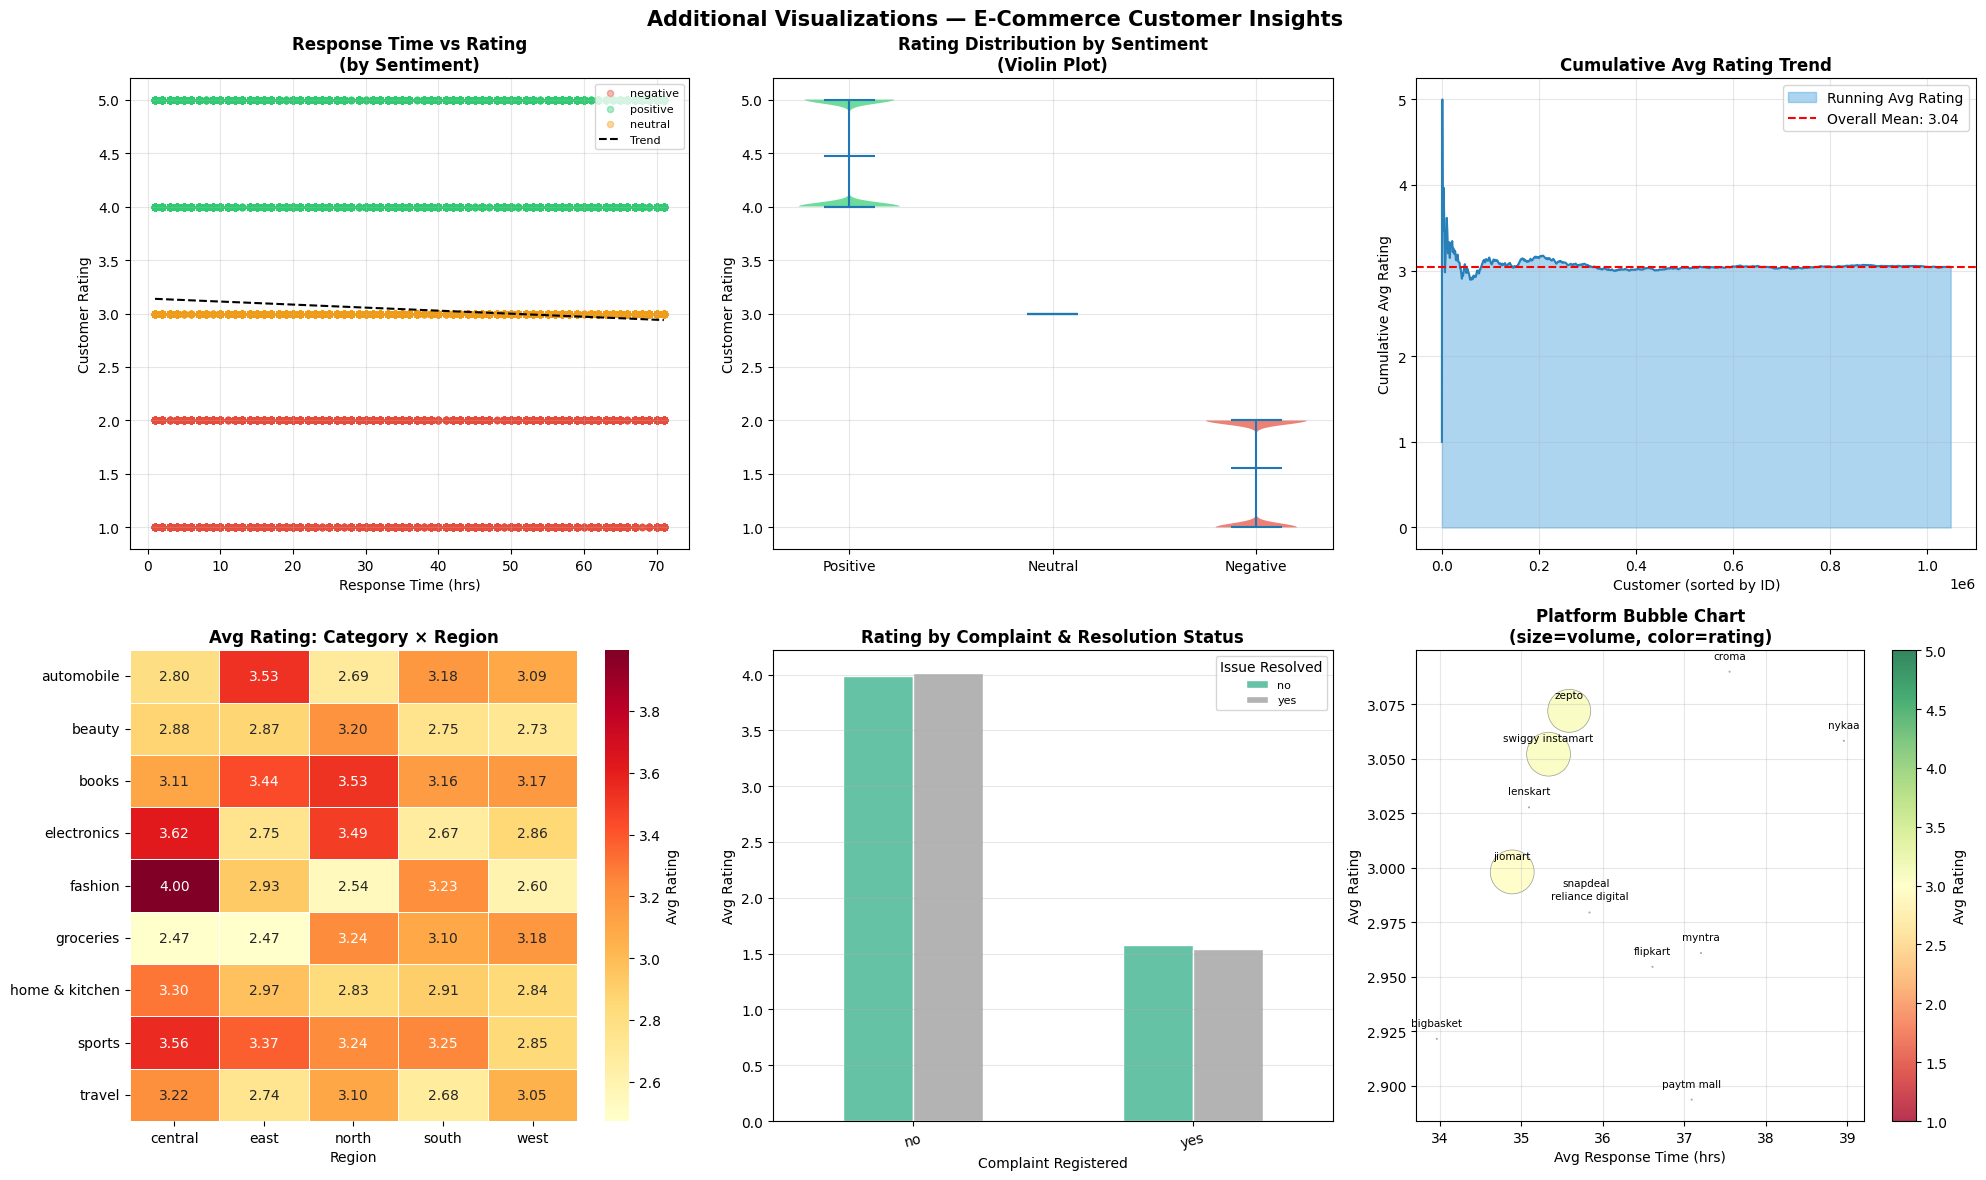

Additional visualizations saved.


In [8]:
print("=" * 60)
print("ADDITIONAL MATPLOTLIB VISUALIZATIONS")
print("=" * 60)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle("Additional Visualizations — E-Commerce Customer Insights",
             fontsize=15, fontweight='bold')

# ── 1. Scatter: Response Time vs Rating (colored by sentiment) ────────────────
ax = axes[0, 0]
sent_colors = {'positive': '#2ecc71', 'neutral': '#f39c12', 'negative': '#e74c3c'}
for sent in df_clean['sentiment'].dropna().unique():
    subset = df_clean[df_clean['sentiment'] == sent]
    ax.scatter(subset['response_time_hours'], subset['customer_rating'],
               alpha=0.4, s=20, color=sent_colors.get(sent, 'gray'), label=sent)
# Add linear trendline
rt_clean = df_clean[['response_time_hours','customer_rating']].dropna()
z = np.polyfit(rt_clean['response_time_hours'], rt_clean['customer_rating'], 1)
p = np.poly1d(z)
ax.plot(sorted(rt_clean['response_time_hours']), p(sorted(rt_clean['response_time_hours'])),
        "k--", linewidth=1.5, label='Trend')
ax.set_title("Response Time vs Rating\n(by Sentiment)", fontweight='bold')
ax.set_xlabel("Response Time (hrs)")
ax.set_ylabel("Customer Rating")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ── 2. Violin Plot: Rating by Sentiment ──────────────────────────────────────
ax = axes[0, 1]
sentiment_groups = [df_clean[df_clean['sentiment'] == s]['customer_rating'].dropna().values
                    for s in ['positive', 'neutral', 'negative']]
vp = ax.violinplot(sentiment_groups, positions=[1, 2, 3], showmedians=True, showmeans=True)
for pc, color in zip(vp['bodies'], ['#2ecc71', '#f39c12', '#e74c3c']):
    pc.set_facecolor(color)
    pc.set_alpha(0.7)
ax.set_xticks([1, 2, 3])
ax.set_xticklabels(['Positive', 'Neutral', 'Negative'])
ax.set_title("Rating Distribution by Sentiment\n(Violin Plot)", fontweight='bold')
ax.set_ylabel("Customer Rating")
ax.grid(alpha=0.3)

# ── 3. Area Chart: Cumulative Ratings over Customer IDs ───────────────────────
ax = axes[0, 2]
df_sorted = df_clean.sort_values('customer_id')
cumulative_rating = df_sorted['customer_rating'].expanding().mean().values
ax.fill_between(range(len(cumulative_rating)), cumulative_rating,
                alpha=0.4, color='#3498db', label='Running Avg Rating')
ax.plot(cumulative_rating, color='#2980b9', linewidth=1.5)
ax.axhline(df_clean['customer_rating'].mean(), color='red', linestyle='--',
           linewidth=1.5, label=f"Overall Mean: {df_clean['customer_rating'].mean():.2f}")
ax.set_title("Cumulative Avg Rating Trend", fontweight='bold')
ax.set_xlabel("Customer (sorted by ID)")
ax.set_ylabel("Cumulative Avg Rating")
ax.legend()
ax.grid(alpha=0.3)

# ── 4. Heatmap: Product Category vs Region (Avg Rating) ─────────────────────
ax = axes[1, 0]
pivot = df_clean.pivot_table(values='customer_rating',
                              index='product_category', columns='region', aggfunc='mean')
sns.heatmap(pivot, ax=ax, cmap='YlOrRd', annot=True, fmt='.2f',
            linewidths=0.5, cbar_kws={'label': 'Avg Rating'})
ax.set_title("Avg Rating: Category × Region", fontweight='bold')
ax.set_xlabel("Region")
ax.set_ylabel("")

# ── 5. Subgroup Bar: Complaint + Issue Resolved vs Avg Rating ─────────────────
ax = axes[1, 1]
cross = df_clean.groupby(['complaint_registered', 'issue_resolved'])['customer_rating'].mean().unstack()
cross.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white')
ax.set_title("Rating by Complaint & Resolution Status", fontweight='bold')
ax.set_xlabel("Complaint Registered")
ax.set_ylabel("Avg Rating")
ax.set_xticklabels(cross.index, rotation=15)
ax.legend(title='Issue Resolved', fontsize=8)
ax.grid(alpha=0.3, axis='y')

# ── 6. Platform Group — Bubble Chart (Count vs Avg Rating) ────────────────────
ax = axes[1, 2]
plat_stats = df_clean.groupby('platform_group').agg(
    count=('customer_id', 'count'),
    avg_rating=('customer_rating', 'mean'),
    avg_response=('response_time_hours', 'mean')
).dropna().reset_index()
top_plat = plat_stats.nlargest(12, 'count')
scatter = ax.scatter(top_plat['avg_response'], top_plat['avg_rating'],
                     s=top_plat['count'] / top_plat['count'].max() * 1000,
                     c=top_plat['avg_rating'], cmap='RdYlGn', vmin=1, vmax=5,
                     alpha=0.8, edgecolors='gray', linewidths=0.5)
plt.colorbar(scatter, ax=ax, label='Avg Rating')
for _, row in top_plat.iterrows():
    ax.annotate(row['platform_group'], (row['avg_response'], row['avg_rating']),
                fontsize=7.5, ha='center', va='bottom',
                xytext=(0, 8), textcoords='offset points')
ax.set_title("Platform Bubble Chart\n(size=volume, color=rating)", fontweight='bold')
ax.set_xlabel("Avg Response Time (hrs)")
ax.set_ylabel("Avg Rating")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("additional_visualizations.png", dpi=150, bbox_inches='tight')
plt.show()
print("Additional visualizations saved.")

DATASET: E-Commerce Customer Feedback (5,566 Records)
   Columns: customer_id, region, product_category, purchase_channel,
            platform, customer_rating, sentiment, response_time_hours,
            issue_resolved, complaint_registered, delivery_rating,
            delivery_time_min, platform_group

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 PART A — VISUAL ANALYTICS DASHBOARD
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✔ 12-panel dashboard with bar charts, pie charts, box plots,
    stacked bars, histograms, grouped bars, and correlation heatmap
  ✔ Region-wise, platform-wise, category-wise breakdowns
  ✔ Sentiment and complaint analysis

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 PART B — TIME SERIES FORECASTING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✔ Time series constructed from customer records (100-record periods)
  ✔ Holt-Winters Double Exponential Smoothing applied
  ✔ 10-period forecast with confidence intervals
  ✔ Rolling statistics and residual analysis plotted

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 PART C — TREND & PATTERN ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✔ 5 curve fits applied: Linear, Polynomial, Logarithmic,
    Exponential, Power
  ✔ R² scores computed and compared for each model
  ✔ Best-fit model identified per variable
  ✔ Residual analysis included

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 ADDITIONAL MATPLOTLIB VISUALIZATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  ✔ Scatter plot, Violin plot, Area chart,
    Heatmap, Grouped bar, Bubble chart

# Assignment 4